# Fraud Shield AI — Exploratory Data Analysis

Goal: understand the data well enough that every later modeling decision
(feature choice, imbalance handling, model family) is backed by something
seen here rather than assumed.

Sections:
1. Data overview & quality checks
2. Class imbalance
3. Transaction amount
4. Category / merchant patterns
5. Temporal patterns
6. Geospatial: cardholder-merchant distance
7. Customer demographics
8. City population (urban vs rural)
9. Transaction velocity & spending deviation (engineered features)
10. Correlation overview
11. Summary of findings

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from config import TARGET_COL, AMOUNT_COL, DATETIME_COL
from data_loader import load_train, load_val, load_test
from features import (
    add_distance_feature,
    add_datetime_features,
    add_customer_age,
    add_velocity_features,
    add_spending_deviation,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)


## 1. Data overview & quality checks

In [2]:
train_df = load_train()
val_df = load_val()
test_df = load_test()

print(f"train: {train_df.shape}")
print(f"val:   {val_df.shape}")
print(f"test:  {test_df.shape}")

train_df.head()


train: (1102173, 22)
val:   (194502, 22)
test:  (555719, 22)


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [3]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1102173 entries, 0 to 1102172
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1102173 non-null  datetime64[us]
 1   cc_num                 1102173 non-null  int64         
 2   merchant               1102173 non-null  str           
 3   category               1102173 non-null  str           
 4   amt                    1102173 non-null  float64       
 5   first                  1102173 non-null  str           
 6   last                   1102173 non-null  str           
 7   gender                 1102173 non-null  str           
 8   street                 1102173 non-null  str           
 9   city                   1102173 non-null  str           
 10  state                  1102173 non-null  str           
 11  zip                    1102173 non-null  int64         
 12  lat                    1102173 non-null

In [4]:
# Missing values
missing = train_df.isna().sum()
missing = missing[missing > 0]
print("Columns with missing values:" if len(missing) else "No missing values.")
missing

No missing values.


Series([], dtype: int64)

In [5]:
# Duplicate rows / duplicate transaction IDs
print("Fully duplicated rows:", train_df.duplicated().sum())
if "trans_num" in train_df.columns:
    print("Duplicate trans_num:", train_df["trans_num"].duplicated().sum())


Fully duplicated rows: 0
Duplicate trans_num: 0


**Interpretation**
1. No missing values observed
2. No duplicates 

## 2. Class imbalance

is_fraud
0    1095800
1       6373
Name: count, dtype: int64
Fraud rate: 0.5782%
Non-Fraud rate: 99.4218%


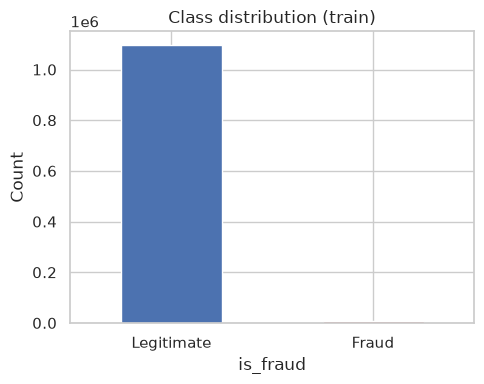

In [9]:
fraud_counts = train_df[TARGET_COL].value_counts()
fraud_rate = train_df[TARGET_COL].mean()

print(fraud_counts)
print(f"Fraud rate: {fraud_rate:.4%}")
print(f"Non-Fraud rate: {1-fraud_rate:.4%}")

fig, ax = plt.subplots(figsize=(5, 4))
fraud_counts.plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Legitimate", "Fraud"], rotation=0)
ax.set_ylabel("Count")
ax.set_title("Class distribution (train)")
plt.tight_layout()
plt.show()



**Interpretation:** The dataset is imbalance
1. Only 0.5782% are fraudulent transactions
2. While 99.4218% are legitimate transactions

## 3. Transaction amount

              count        mean         std   min     25%     50%     75%       max
is_fraud                                                                           
0         1095800.0   67.643714  153.384315  1.00    9.61   47.24   82.49  28948.90
1            6373.0  530.986997  391.081870  1.06  243.63  392.42  901.83   1371.81


/tmp/ipykernel_14495/3107635406.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(["Legitimate", "Fraud"])


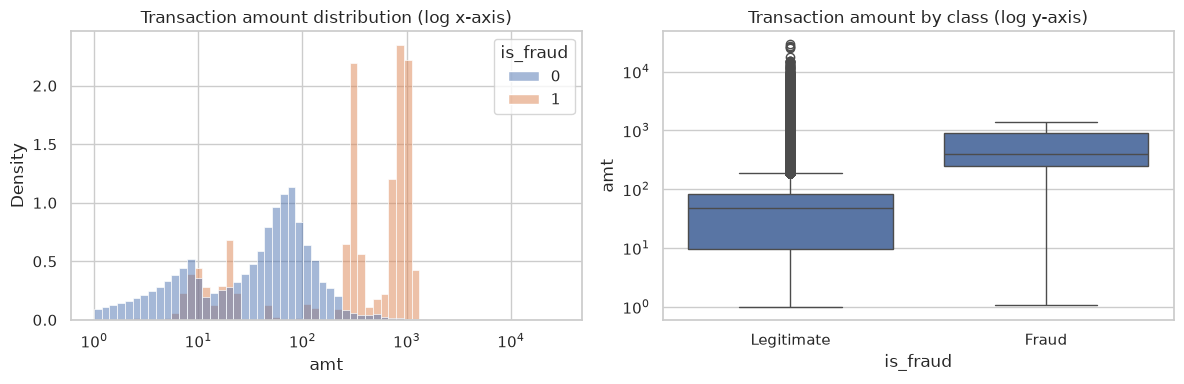

In [18]:
print(train_df.groupby(TARGET_COL)[AMOUNT_COL].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=train_df, x=AMOUNT_COL, hue=TARGET_COL, bins=60,
    log_scale=(True, False), stat="density", common_norm=False, ax=axes[0],
)
axes[0].set_title("Transaction amount distribution (log x-axis)")

sns.boxplot(data=train_df, x=TARGET_COL, y=AMOUNT_COL, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_xticklabels(["Legitimate", "Fraud"])
axes[1].set_title("Transaction amount by class (log y-axis)")

plt.tight_layout()
plt.show()


**Interpretation:**
1. The fraudulent transactions are mostly much higher in amount than legitimate ones.
2. They look originate from different distributions


## 4. Category / merchant patterns

,fraud_rate,n_transactions
category,,
shopping_net,0.017641,82932
misc_net,0.014507,53629
grocery_pos,0.014115,104993
shopping_pos,0.007143,98974
gas_transport,0.004694,111834
misc_pos,0.003100,67743
grocery_net,0.003010,38543
travel,0.002986,34496
entertainment,0.002514,79966


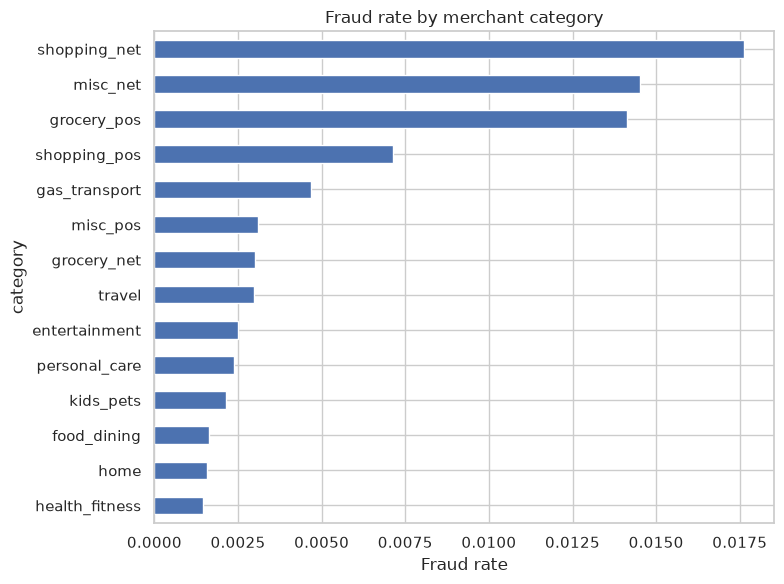

In [27]:
if "category" in train_df.columns:
    fraud_by_category = (
        train_df.groupby("category")[TARGET_COL]
        .agg(["mean", "count"])
        .rename(columns={"mean": "fraud_rate", "count": "n_transactions"})
        .sort_values("fraud_rate", ascending=False)
    )
    display(fraud_by_category)

    fig, ax = plt.subplots(figsize=(8, 6))
    fraud_by_category["fraud_rate"].plot(kind="barh", ax=ax)
    ax.set_xlabel("Fraud rate")
    ax.set_title("Fraud rate by merchant category")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


**Interpretation:** 
1. Shopping_net, misc_net and grocery_pos categories are at high risk of being fraudulent.
2. food_dining, home and health_fitness categories have high chances of being legitimate.

## 5. Temporal patterns

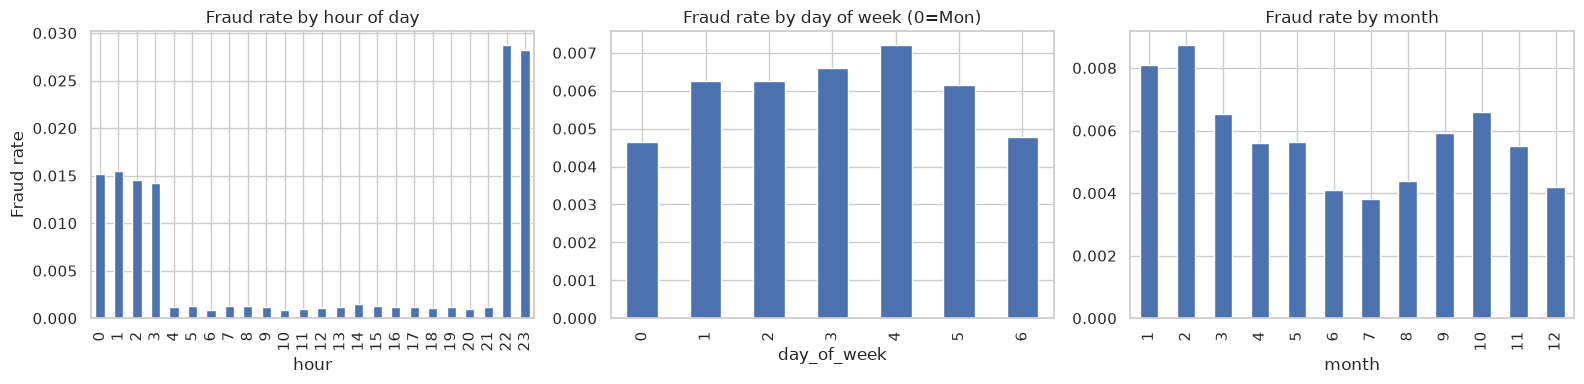

In [28]:
train_time = add_datetime_features(train_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

train_time.groupby("hour")[TARGET_COL].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Fraud rate by hour of day")
axes[0].set_ylabel("Fraud rate")

train_time.groupby("day_of_week")[TARGET_COL].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Fraud rate by day of week (0=Mon)")

train_time.groupby("month")[TARGET_COL].mean().plot(kind="bar", ax=axes[2])
axes[2].set_title("Fraud rate by month")

plt.tight_layout()
plt.show()


**Interpretation:** 
1. Most of the fruadulent transactions happen from 10pm to 3am.
2. Friday has highest fraudulent transaction rate but there are not much difference compared to other days
3. Higher fraudulent rates take place between January and March.

## 6. Geospatial: cardholder-merchant distance

/tmp/ipykernel_14495/1693425006.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax2.set_xticklabels(["Legitimate", "Fraud"])


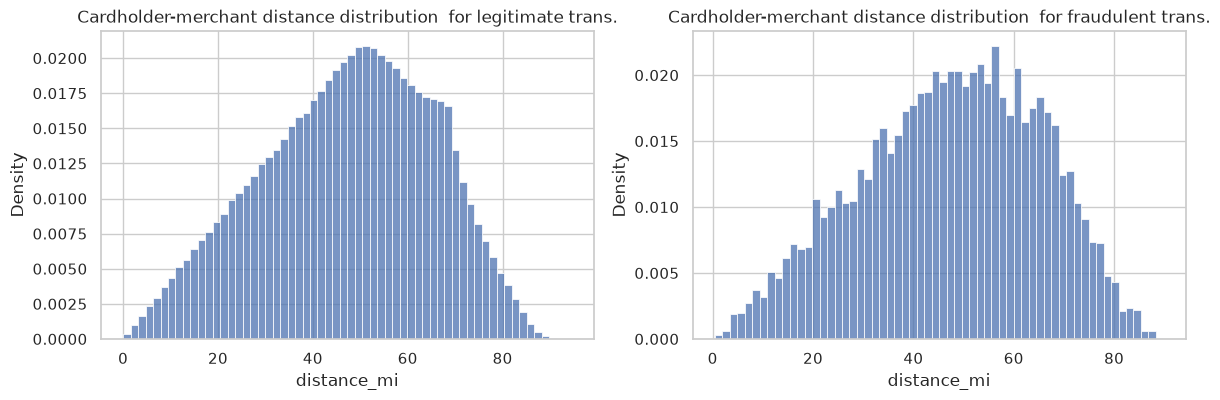

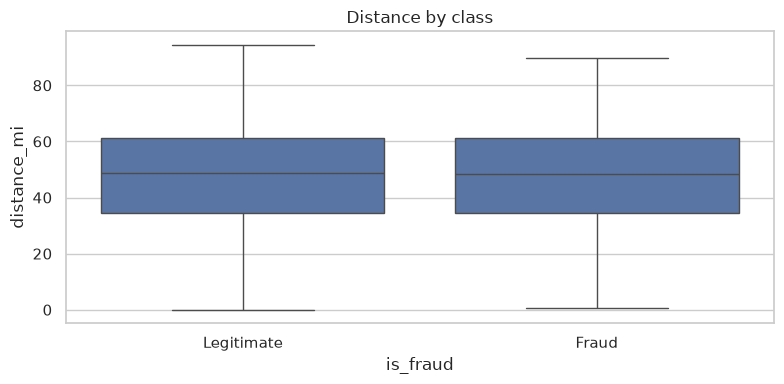

              count      mean        std       min        25%        50%        75%        max
is_fraud                                                                                      
0         1095800.0  47.28937  18.091383  0.013829  34.381822  48.601267  61.198696  94.527058
1            6373.0  47.35174  17.822780  0.459078  34.543668  48.382757  61.087946  89.807600


In [45]:
train_geo = add_distance_feature(train_df)

fig, axes = plt.subplots(1,2, figsize=(14, 4))

sns.histplot(
    data=train_geo[train_geo[TARGET_COL]==0], x="distance_mi",  bins=60,
    stat="density", common_norm=False, ax=axes[0],
)
axes[0].set_title("Cardholder-merchant distance distribution  for legitimate trans.")


sns.histplot(
    data=train_geo[train_geo[TARGET_COL]==1], x="distance_mi", bins=60,
    stat="density", common_norm=False, ax=axes[1],
)
axes[1].set_title("Cardholder-merchant distance distribution  for fraudulent trans.")

fig, ax2 = plt.subplots(figsize=(8, 4))

sns.boxplot(data=train_geo, x=TARGET_COL, y="distance_mi", ax=ax2)
ax2.set_xticklabels(["Legitimate", "Fraud"])
ax2.set_title("Distance by class")

plt.tight_layout()
plt.show()

print(train_geo.groupby(TARGET_COL)["distance_mi"].describe())


**Interpretation:** 
1. There is no difference observed for the distance between customer address and transaction location for fraudulent and legitimate transactions 

## 7. Customer demographics

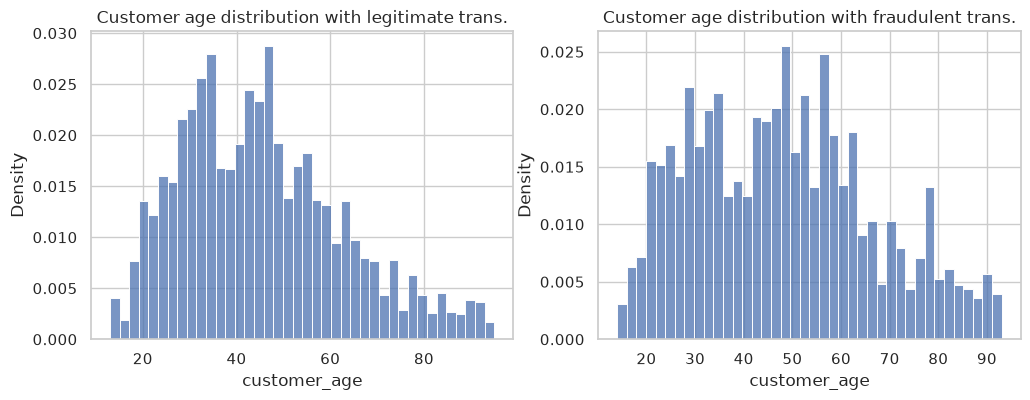

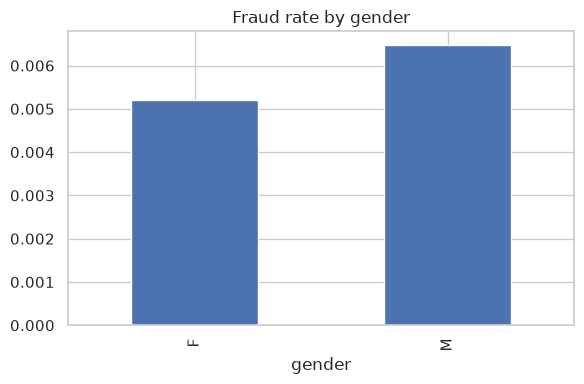

In [46]:
if "dob" in train_df.columns:
    train_demo = add_customer_age(train_df)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(
        data=train_demo[train_demo[TARGET_COL]==0], x="customer_age", bins=40,
        stat="density", common_norm=False, ax=axes[0],
    )
    axes[0].set_title("Customer age distribution with legitimate trans.")
  
    sns.histplot(
        data=train_demo[train_demo[TARGET_COL]==1], x="customer_age", bins=40,
        stat="density", common_norm=False, ax=axes[1],
    )
    axes[1].set_title("Customer age distribution with fraudulent trans.")

    fig, ax2 = plt.subplots( figsize=(6, 4))

    if "gender" in train_demo.columns:
        fraud_by_gender = train_demo.groupby("gender")[TARGET_COL].mean()
        fraud_by_gender.plot(kind="bar", ax=ax2)
        ax2.set_title("Fraud rate by gender")

    plt.tight_layout()
    plt.show()


**Interpretation:** 
1. The graph does not show clearly what age range has high fraudulent rate.
2. Males have higher slightly fraudulent rate.

**Your interpretation:** does population density (rural vs urban
cardholders) relate to fraud rate?


## 9. Transaction velocity & spending deviation (engineered features)

These are two of the higher-effort engineered features named in the
project brief. Computing them properly requires each card's *full*
chronological history (not just one split), so this uses
`load_combined_sorted()` rather than `train_df` alone -- see
`src/data_loader.py` and `src/features.py` for how the leakage-safety is
handled (rolling windows with `closed="left"`, expanding means shifted by
one transaction).

**Note:** `add_velocity_features` groups by card and computes rolling
counts/sums -- on ~1.85M rows this can take a minute or two. That's
expected, not a hang.


In [48]:
from data_loader import load_combined_sorted

combined = load_combined_sorted()
print(f"Combined: {combined.shape}")

combined = add_velocity_features(combined, windows=("1h", "24h"))
combined = add_spending_deviation(combined)

# Pull the train-split rows back out for this exploration
train_engineered = combined[combined["split"] == "train"]
train_engineered.head()


Combined: (1852394, 23)


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,split,txn_count_1h,txn_amt_sum_1h,txn_count_24h,txn_amt_sum_24h,amt_zscore_vs_card_history
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,train,0.0,0.0,0.0,0.0,0.000000
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,train,0.0,0.0,0.0,0.0,0.000000
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,train,0.0,0.0,0.0,0.0,5.883680
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,train,0.0,0.0,0.0,0.0,-0.064442
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,train,0.0,0.0,0.0,0.0,-0.073495


/tmp/ipykernel_14495/1494364217.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Legitimate", "Fraud"])
/tmp/ipykernel_14495/1494364217.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(["Legitimate", "Fraud"])
/tmp/ipykernel_14495/1494364217.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[2].set_xticklabels(["Legitimate", "Fraud"])


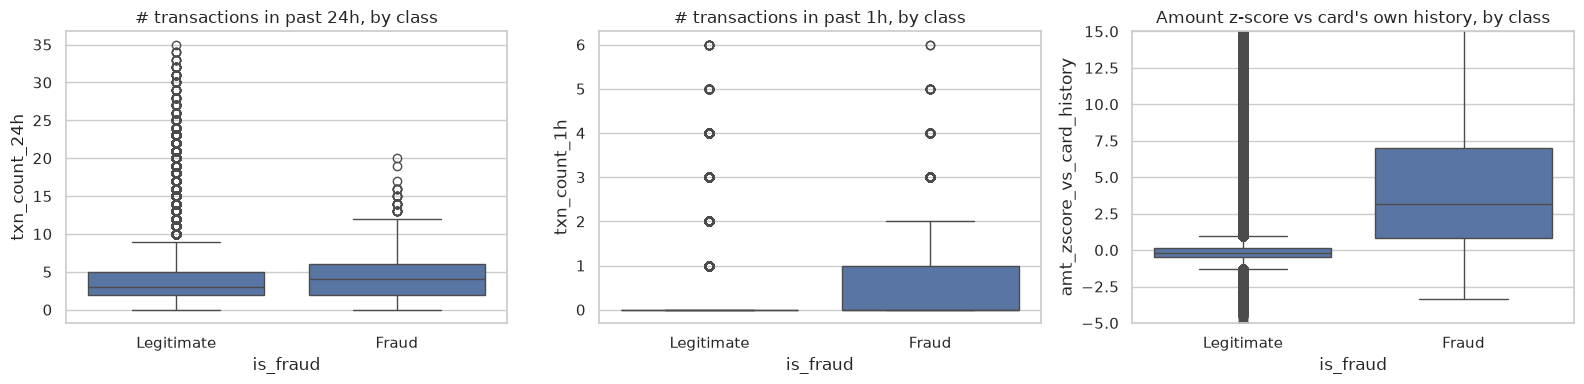

is_fraud                                     0            1
txn_count_1h               count  1.095800e+06  6373.000000
                           mean   1.881803e-01     0.666876
                           std    4.583511e-01     0.945616
                           min    0.000000e+00     0.000000
                           25%    0.000000e+00     0.000000
                           50%    0.000000e+00     0.000000
                           75%    0.000000e+00     1.000000
                           max    6.000000e+00     6.000000
txn_count_24h              count  1.095800e+06  6373.000000
                           mean   3.906843e+00     4.245724
                           std    3.136916e+00     2.457013
                           min    0.000000e+00     0.000000
                           25%    2.000000e+00     2.000000
                           50%    3.000000e+00     4.000000
                           75%    5.000000e+00     6.000000
                           max    3.5000

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=train_engineered, x=TARGET_COL, y="txn_count_24h", ax=axes[0])
axes[0].set_title("# transactions in past 24h, by class")
axes[0].set_xticklabels(["Legitimate", "Fraud"])

sns.boxplot(data=train_engineered, x=TARGET_COL, y="txn_count_1h", ax=axes[1])
axes[1].set_title("# transactions in past 1h, by class")
axes[1].set_xticklabels(["Legitimate", "Fraud"])

sns.boxplot(
    data=train_engineered, x=TARGET_COL, y="amt_zscore_vs_card_history", ax=axes[2]
)
axes[2].set_ylim(-5, 15)  # z-scores have a long tail; clip for readability
axes[2].set_title("Amount z-score vs card's own history, by class")
axes[2].set_xticklabels(["Legitimate", "Fraud"])

plt.tight_layout()
plt.show()

print(train_engineered.groupby(TARGET_COL)[
    ["txn_count_1h", "txn_count_24h", "amt_zscore_vs_card_history"]
].describe().T)


**Your interpretation:** do fraudulent transactions tend to come in bursts
(higher velocity) or stand out from the card's own typical spend (higher
z-score)? These are exactly the "impactful derived features" the grading
rubric calls out -- if they show a clear separation between classes here,
that's your evidence they're worth including in Milestone 3's models, and
it's evidence you can cite directly in your report.
1. The fraudulent tansactions tend to happen to short time intervals, much higher within 1 hour or 24 hours compared to legitimate transactions.
2. The fraudulent transactions have higher deviations compared to legitimate.

## 10. Correlation overview

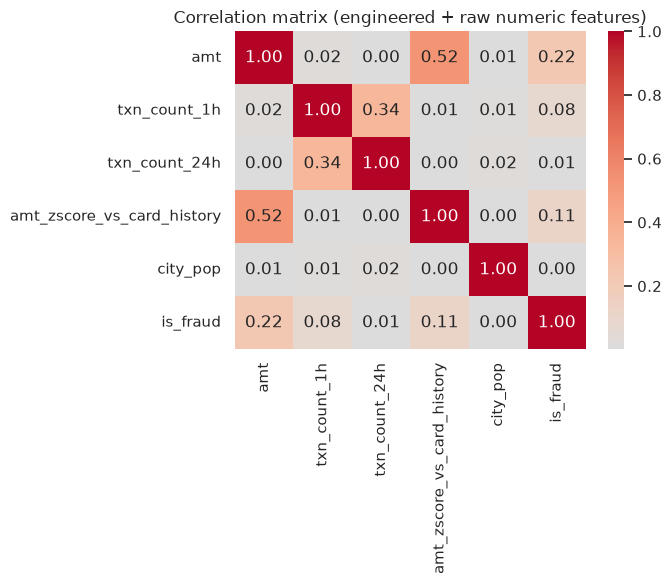

In [50]:
numeric_cols = [
    AMOUNT_COL, "distance_mi" if "distance_mi" in combined.columns else None,
    "txn_count_1h", "txn_count_24h", "amt_zscore_vs_card_history",
    "city_pop", TARGET_COL,
]
numeric_cols = [c for c in numeric_cols if c and c in train_engineered.columns]

corr_df = add_distance_feature(train_engineered) if "distance_km" not in train_engineered.columns else train_engineered
corr = corr_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix (engineered + raw numeric features)")
plt.tight_layout()
plt.show()


**Your interpretation:** 
1. The "amt" shows the highest correlation to faud status
2. The "city_pop" shows the lowest correlation to faud status


## 11. Summary of findings

Fill this in from what you actually observed above -- this section is
what turns the notebook into report material. Suggested structure:

- **Class imbalance:** fraud rate and what it implies for metric choice.
- **Amount:** how fraud amounts differ from legitimate ones (if at all).
- **Category:** which merchant categories carry more risk.
- **Time:** any hour/day/month pattern.
- **Distance:** whether cardholder-merchant distance separates the classes.
- **Demographics:** any age/population pattern, and any fairness caveat.
- **Velocity / spending deviation:** whether these engineered features
  show a clear separation between fraud and legitimate transactions --
  this is your evidence for which engineered features carry into
  Milestone 3 (baseline supervised models).